# Tutorial: PyTorch Deep Neural Networks Mastery Guide

Audience:
- Learners who know the main machine-learning ideas and now want a reliable, professional PyTorch workflow for deep neural networks.
- Anyone moving from course notebooks to their own reproducible experiments.

Prerequisites:
- Python functions, classes, loops, and dictionaries.
- Basic classification concepts: features, labels, loss, validation, and overfitting.

Learning goals:
- Build configurable deep neural networks with `nn.Module`.
- Train them through a reusable trainer class with early stopping.
- Choose and compare activation functions, dropout, batch normalisation, and weight decay.
- Tune hyperparameters with Optuna without touching the test set.
- Use both random train/validation/test splits and a leakage-safe walk-forward framework.


## Outline

1. Setup and device selection for macOS, Windows, and CPU
2. Create one ordered classification dataset
3. Standardise data and build mini-batches
4. Understand common activation functions
5. Create a configurable `nn.Module` model
6. Train through reusable `EarlyStopping` and `BinaryTrainer` classes
7. Run a normal random-split experiment
8. Tune architecture and training hyperparameters with Optuna
9. Evaluate a selected model once on the test set
10. Run the same DNN in an expanding walk-forward framework

The data is synthetic so the notebook can focus on deep-learning mechanics. The same classes work with a real numeric tabular dataset once you replace the data-preparation cells.


In [1]:
from __future__ import annotations

# If your kernel does not have the packages yet, uncomment the next line.
# %pip install torch matplotlib optuna

import copy
import random
from dataclasses import dataclass, field

import matplotlib.pyplot as plt
import optuna
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42


def set_seed(seed: int = SEED) -> None:
    # Set the random seeds used in this notebook.
    random.seed(seed)
    torch.manual_seed(seed)


set_seed()

# Apple-silicon Macs use MPS (Metal). NVIDIA GPUs use CUDA.
# The CPU fallback keeps every later cell portable.
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    DEVICE_NAME = "Apple GPU via MPS"
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    DEVICE_NAME = "NVIDIA GPU via CUDA"
else:
    DEVICE = torch.device("cpu")
    DEVICE_NAME = "CPU"

optuna.logging.set_verbosity(optuna.logging.WARNING)

print("PyTorch version:", torch.__version__)
print("Optuna version: ", optuna.__version__)
print("Selected device:", DEVICE, f"({DEVICE_NAME})")


PyTorch version: 2.10.0
Optuna version:  4.7.0
Selected device: mps (Apple GPU via MPS)


### Device reference — macOS, Windows, and Linux

The notebook uses `DEVICE` everywhere, so the modelling code does not change across computers.

- **Apple-silicon Mac:** use `mps`, detected by `torch.backends.mps.is_available()`.
- **Windows/Linux with an NVIDIA GPU:** use `cuda`, detected by `torch.cuda.is_available()`.
- **CPU fallback:** works everywhere, including Intel Macs without MPS support.

PyTorch documents the `mps` device in its [MPS backend guide](https://docs.pytorch.org/docs/stable/notes/mps.html) and CUDA detection through [`torch.cuda.is_available()`](https://docs.pytorch.org/docs/stable/generated/torch.cuda.is_available.html).


## Step 1 - Build ordered, reproducible practice data

Every row represents one customer observation collected in time order. The label is whether that customer converts. We intentionally include interaction effects, non-linear effects, and a small time component so that a DNN has something meaningful to learn.

Keeping the rows ordered lets us later demonstrate the difference between a normal random split and a walk-forward evaluation.


In [2]:
feature_names = [
    "website_visits",
    "time_on_site",
    "email_opens",
    "previous_purchases",
    "discount_interest",
    "support_tickets",
    "days_since_signup",
    "product_pages_viewed",
]


def make_ordered_customer_data(
    n_samples: int = 3_000,
    seed: int = SEED,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    # Create reproducible numeric features in chronological row order.
    generator = torch.Generator().manual_seed(seed)
    time_index = torch.arange(n_samples, dtype=torch.float32)
    features = torch.randn(n_samples, len(feature_names), generator=generator)

    # Give one feature a visible seasonal pattern over time.
    features[:, 7] += 0.8 * torch.sin(time_index / 90)

    linear_signal = (
        0.9 * features[:, 0]
        + 0.7 * features[:, 1]
        + 0.5 * features[:, 2]
        + 0.6 * features[:, 3]
        - 0.7 * features[:, 5]
        - 0.5 * features[:, 6]
    )
    nonlinear_signal = (
        1.2 * features[:, 0] * features[:, 4]
        - 0.8 * features[:, 1].square()
        + 0.7 * torch.sin(features[:, 7])
        + 0.25 * torch.sin(time_index / 180)
    )
    noisy_logit = linear_signal + nonlinear_signal + 0.35 * torch.randn(n_samples, generator=generator)
    labels = torch.bernoulli(torch.sigmoid(noisy_logit), generator=generator).unsqueeze(1)

    return features.float(), labels.float(), time_index


raw_features, labels, time_index = make_ordered_customer_data()

print("Feature matrix shape:", tuple(raw_features.shape))
print("Target matrix shape: ", tuple(labels.shape))
print(f"Positive-class rate: {labels.mean().item():.1%}")


Feature matrix shape: (3000, 8)
Target matrix shape:  (3000, 1)
Positive-class rate: 39.0%


In [3]:
print("First three observations, first four features:")
print(raw_features[:3, :4])
print("\nFirst three labels:", labels[:3].squeeze(1).tolist())
print("First three time steps:", time_index[:3].tolist())


First three observations, first four features:
tensor([[ 1.9269,  1.4873,  0.9007, -2.1055],
        [-0.7521,  1.6487, -0.3925, -1.4036],
        [ 1.6423, -0.1596, -0.4974,  0.4396]])

First three labels: [1.0, 1.0, 0.0]
First three time steps: [0.0, 1.0, 2.0]


## Step 2 - Standardisation and mini-batches

Neural networks usually train more smoothly when numeric inputs have comparable scales. The standardiser below is deliberately small: call `fit` only on training rows, then use the same statistics to transform validation and test rows.

This rule prevents data leakage in both the random-split and walk-forward examples.


In [4]:
class TensorStandardizer:
    # A minimal training-data-only standardiser for PyTorch tensors.
    def fit(self, values: torch.Tensor) -> "TensorStandardizer":
        self.mean = values.mean(dim=0, keepdim=True)
        self.std = values.std(dim=0, keepdim=True).clamp_min(1e-6)
        return self

    def transform(self, values: torch.Tensor) -> torch.Tensor:
        return (values - self.mean) / self.std


def make_loader(
    features: torch.Tensor,
    targets: torch.Tensor,
    batch_size: int,
    shuffle: bool,
) -> DataLoader:
    dataset = TensorDataset(features, targets)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def random_train_validation_test_split(
    features: torch.Tensor,
    targets: torch.Tensor,
    train_fraction: float = 0.70,
    validation_fraction: float = 0.15,
    seed: int = SEED,
) -> dict[str, tuple[torch.Tensor, torch.Tensor]]:
    # Random splits are valid only when rows are independent of time.
    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(features), generator=generator)
    train_end = int(train_fraction * len(features))
    validation_end = train_end + int(validation_fraction * len(features))

    split_indices = {
        "train": indices[:train_end],
        "validation": indices[train_end:validation_end],
        "test": indices[validation_end:],
    }
    return {
        name: (features[split], targets[split])
        for name, split in split_indices.items()
    }


## Step 3 - Activation functions give a DNN its non-linearity

Without activation functions, several dense layers collapse into one linear transformation. `ReLU` is the usual baseline; `LeakyReLU`, `ELU`, `GELU`, and `SiLU` are useful alternatives.

There is no universal winner. Start with ReLU or GELU, then compare alternatives through validation results rather than intuition alone.


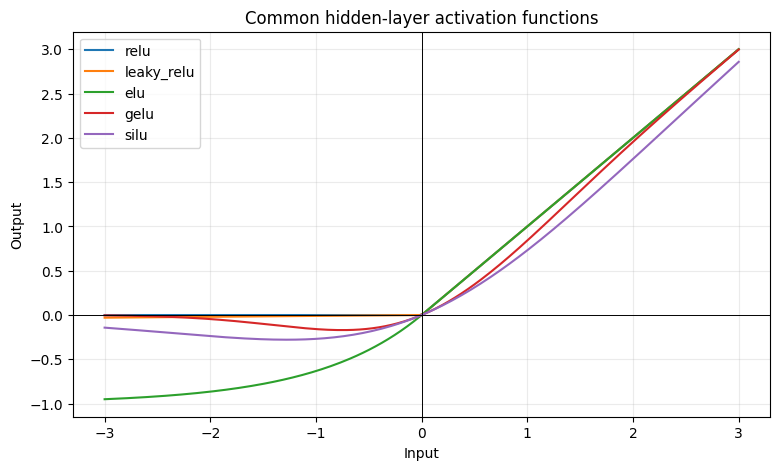

In [5]:
activation_layers = {
    "relu": nn.ReLU,
    "leaky_relu": nn.LeakyReLU,
    "elu": nn.ELU,
    "gelu": nn.GELU,
    "silu": nn.SiLU,
}

values = torch.linspace(-3, 3, 200)
plt.figure(figsize=(9, 5))

for name, activation_class in activation_layers.items():
    plt.plot(values, activation_class()(values), label=name)

plt.axhline(0, color="black", linewidth=0.7)
plt.axvline(0, color="black", linewidth=0.7)
plt.title("Common hidden-layer activation functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## Step 4 - Create the model with `nn.Module`

`MLPClassifier` is the model class. It accepts architecture choices rather than hard-coding one network:

- `hidden_sizes` controls depth and width;
- `activation` chooses the non-linearity;
- `dropout` reduces over-reliance on individual hidden units;
- `use_batch_norm` normalises hidden activations within mini-batches.

The final layer returns one **raw logit**. That is exactly what `BCEWithLogitsLoss` expects, so do not add a sigmoid layer to this model.


In [6]:
class MLPClassifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        hidden_sizes: tuple[int, ...] = (64, 32),
        activation: str = "relu",
        dropout: float = 0.0,
        use_batch_norm: bool = False,
    ) -> None:
        super().__init__()

        if activation not in activation_layers:
            available = ", ".join(activation_layers)
            raise ValueError(f"Unknown activation '{activation}'. Choose one of: {available}")

        layers: list[nn.Module] = []
        current_size = input_size

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(current_size, hidden_size))

            if use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_size))

            layers.append(activation_layers[activation]())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            current_size = hidden_size

        layers.append(nn.Linear(current_size, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.network(inputs)


def count_trainable_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


example_model = MLPClassifier(
    input_size=len(feature_names),
    hidden_sizes=(64, 32),
    activation="gelu",
    dropout=0.15,
    use_batch_norm=True,
).to(DEVICE)

print(example_model)
print("Trainable parameters:", count_trainable_parameters(example_model))


MLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)
Trainable parameters: 2881


## Step 5 - Reusable early stopping and training classes

These two classes hold the training mechanics in one place.

- `EarlyStopping` remembers the parameter state with the lowest validation loss and restores it at the end.
- `BinaryTrainer` handles forward passes, loss, gradients, optimiser updates, evaluation, and probabilities.

`model.train()` and `model.eval()` are set in the right place, which matters whenever dropout or batch normalisation is enabled.


In [7]:
@dataclass
class TrainingConfig:
    epochs: int = 100
    batch_size: int = 64
    learning_rate: float = 1e-3
    weight_decay: float = 0.0
    optimizer_name: str = "adamw"
    early_stopping_patience: int = 15
    early_stopping_min_delta: float = 1e-4


@dataclass
class EarlyStopping:
    patience: int
    min_delta: float = 0.0
    best_loss: float = field(default=float("inf"), init=False)
    best_epoch: int = field(default=0, init=False)
    waiting_epochs: int = field(default=0, init=False)
    best_state_dict: dict[str, torch.Tensor] | None = field(default=None, init=False)

    def update(self, validation_loss: float, model: nn.Module, epoch: int) -> bool:
        # Return True only when validation loss has not improved for long enough.
        if validation_loss < self.best_loss - self.min_delta:
            self.best_loss = validation_loss
            self.best_epoch = epoch
            self.waiting_epochs = 0
            self.best_state_dict = copy.deepcopy(model.state_dict())
            return False

        self.waiting_epochs += 1
        return self.waiting_epochs >= self.patience

    def restore_best_weights(self, model: nn.Module) -> None:
        if self.best_state_dict is not None:
            model.load_state_dict(self.best_state_dict)


class BinaryTrainer:
    def __init__(self, model: nn.Module, config: TrainingConfig, device: torch.device) -> None:
        self.model = model.to(device)
        self.config = config
        self.device = device
        self.loss_function = nn.BCEWithLogitsLoss()

        optimizers = {
            "adam": torch.optim.Adam,
            "adamw": torch.optim.AdamW,
        }
        if config.optimizer_name not in optimizers:
            raise ValueError("optimizer_name must be 'adam' or 'adamw'.")

        self.optimizer = optimizers[config.optimizer_name](
            self.model.parameters(),
            lr=config.learning_rate,
            weight_decay=config.weight_decay,
        )
        self.history: dict[str, list[float]] = {
            "train_loss": [],
            "train_accuracy": [],
            "validation_loss": [],
            "validation_accuracy": [],
        }
        self.best_epoch = 0

    def _run_loader(self, loader: DataLoader, training: bool) -> tuple[float, float]:
        self.model.train(training)
        total_loss = 0.0
        total_correct = 0
        total_examples = 0

        context = torch.enable_grad() if training else torch.no_grad()
        with context:
            for batch_features, batch_targets in loader:
                batch_features = batch_features.to(self.device)
                batch_targets = batch_targets.to(self.device)

                logits = self.model(batch_features)
                loss = self.loss_function(logits, batch_targets)

                if training:
                    self.optimizer.zero_grad(set_to_none=True)
                    loss.backward()
                    self.optimizer.step()

                predictions = (torch.sigmoid(logits) >= 0.5).float()
                batch_size = len(batch_features)
                total_loss += loss.item() * batch_size
                total_correct += (predictions == batch_targets).sum().item()
                total_examples += batch_size

        return total_loss / total_examples, total_correct / total_examples

    def fit(
        self,
        train_loader: DataLoader,
        validation_loader: DataLoader,
        trial: optuna.Trial | None = None,
        verbose: bool = True,
    ) -> dict[str, list[float]]:
        stopper = EarlyStopping(
            patience=self.config.early_stopping_patience,
            min_delta=self.config.early_stopping_min_delta,
        )

        for epoch in range(1, self.config.epochs + 1):
            train_loss, train_accuracy = self._run_loader(train_loader, training=True)
            validation_loss, validation_accuracy = self._run_loader(validation_loader, training=False)

            self.history["train_loss"].append(train_loss)
            self.history["train_accuracy"].append(train_accuracy)
            self.history["validation_loss"].append(validation_loss)
            self.history["validation_accuracy"].append(validation_accuracy)

            if trial is not None:
                trial.report(validation_loss, step=epoch)
                if trial.should_prune():
                    raise optuna.TrialPruned()

            should_stop = stopper.update(validation_loss, self.model, epoch)

            if verbose and (epoch == 1 or epoch % 10 == 0 or should_stop):
                print(
                    f"Epoch {epoch:>3} | "
                    f"train loss {train_loss:.3f}, train acc {train_accuracy:.1%} | "
                    f"val loss {validation_loss:.3f}, val acc {validation_accuracy:.1%}"
                )

            if should_stop:
                if verbose:
                    print(f"Early stopping after epoch {epoch}.")
                break

        stopper.restore_best_weights(self.model)
        self.best_epoch = stopper.best_epoch
        return self.history

    def evaluate(self, loader: DataLoader) -> tuple[float, float]:
        return self._run_loader(loader, training=False)

    @torch.no_grad()
    def predict_probabilities(self, features: torch.Tensor) -> torch.Tensor:
        self.model.eval()
        logits = self.model(features.to(self.device))
        return torch.sigmoid(logits).cpu()


## Step 6 - Normal random-split workflow

Use a random split when observations are independent and identically distributed: for example, a static customer table where row order is arbitrary. We fit the standardiser on training data only, use validation data for early stopping and model choices, and leave the test set untouched until the selected model is ready.


In [8]:
normal_split = random_train_validation_test_split(raw_features, labels)
x_train_raw, y_train = normal_split["train"]
x_validation_raw, y_validation = normal_split["validation"]
x_test_raw, y_test = normal_split["test"]

normal_standardizer = TensorStandardizer().fit(x_train_raw)
x_train = normal_standardizer.transform(x_train_raw)
x_validation = normal_standardizer.transform(x_validation_raw)
x_test = normal_standardizer.transform(x_test_raw)

baseline_config = TrainingConfig(
    epochs=100,
    batch_size=64,
    learning_rate=1e-3,
    weight_decay=1e-4,
    optimizer_name="adamw",
    early_stopping_patience=15,
)

train_loader = make_loader(x_train, y_train, baseline_config.batch_size, shuffle=True)
validation_loader = make_loader(x_validation, y_validation, baseline_config.batch_size, shuffle=False)
test_loader = make_loader(x_test, y_test, baseline_config.batch_size, shuffle=False)

print("Train rows:     ", len(x_train))
print("Validation rows:", len(x_validation))
print("Test rows:      ", len(x_test))


Train rows:      2100
Validation rows: 450
Test rows:       450


In [9]:
set_seed(SEED)

baseline_model = MLPClassifier(
    input_size=x_train.shape[1],
    hidden_sizes=(64, 32),
    activation="relu",
    dropout=0.10,
    use_batch_norm=False,
)
baseline_trainer = BinaryTrainer(baseline_model, baseline_config, DEVICE)
baseline_history = baseline_trainer.fit(train_loader, validation_loader)

print(f"Restored best baseline weights from epoch {baseline_trainer.best_epoch}.")


Epoch   1 | train loss 0.650, train acc 61.3% | val loss 0.597, val acc 64.9%
Epoch  10 | train loss 0.474, train acc 77.5% | val loss 0.440, val acc 80.4%
Epoch  20 | train loss 0.450, train acc 78.0% | val loss 0.437, val acc 79.6%
Epoch  29 | train loss 0.454, train acc 78.0% | val loss 0.441, val acc 79.1%
Early stopping after epoch 29.
Restored best baseline weights from epoch 14.


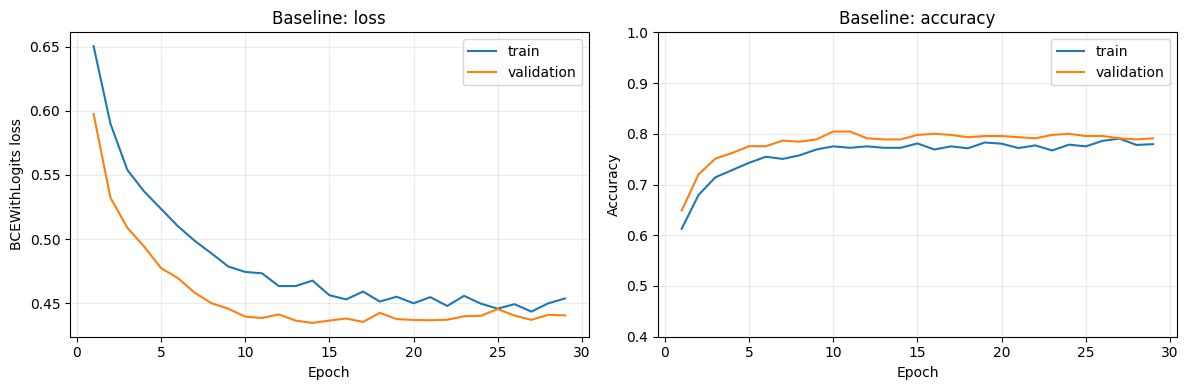

In [10]:
def plot_learning_curves(history: dict[str, list[float]], title_prefix: str) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["validation_loss"], label="validation")
    axes[0].set(title=f"{title_prefix}: loss", xlabel="Epoch", ylabel="BCEWithLogits loss")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(epochs, history["train_accuracy"], label="train")
    axes[1].plot(epochs, history["validation_accuracy"], label="validation")
    axes[1].set(title=f"{title_prefix}: accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0.4, 1.0))
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


plot_learning_curves(baseline_history, "Baseline")


## Step 7 - Tune hyperparameters with Optuna

Optuna repeatedly samples a candidate configuration, trains it using the **training** and **validation** loaders only, and retains the configuration with the lowest validation loss. The test loader is intentionally absent from the objective function.

This compact search tunes architecture, activation, dropout, batch normalisation, optimiser, learning rate, and weight decay. Early stopping makes weak trials cheaper; Optuna's median pruner can stop clearly unpromising trials even sooner. Optuna's [study API](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.create_study.html) creates and optimises the search, while each trial provides `suggest_*` methods for candidate parameters.


In [11]:
architecture_options = {
    "small": (32,),
    "medium": (64, 32),
    "deep": (128, 64, 32),
}


def optuna_objective(trial: optuna.Trial) -> float:
    # A unique seed makes each trial reproducible while still varying initial weights.
    set_seed(SEED + trial.number)

    architecture_name = trial.suggest_categorical("architecture", list(architecture_options))
    activation = trial.suggest_categorical("activation", list(activation_layers))
    dropout = trial.suggest_float("dropout", 0.0, 0.40, step=0.05)
    use_batch_norm = trial.suggest_categorical("use_batch_norm", [False, True])

    config = TrainingConfig(
        epochs=80,
        batch_size=64,
        learning_rate=trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True),
        weight_decay=trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        optimizer_name=trial.suggest_categorical("optimizer_name", ["adam", "adamw"]),
        early_stopping_patience=12,
    )
    model = MLPClassifier(
        input_size=x_train.shape[1],
        hidden_sizes=architecture_options[architecture_name],
        activation=activation,
        dropout=dropout,
        use_batch_norm=use_batch_norm,
    )
    trainer = BinaryTrainer(model, config, DEVICE)
    history = trainer.fit(train_loader, validation_loader, trial=trial, verbose=False)

    # The best recorded validation loss is the single value Optuna minimises.
    return min(history["validation_loss"])


sampler = optuna.samplers.TPESampler(seed=SEED)
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)

# Increase n_trials later if runtime is comfortable on your machine.
study.optimize(optuna_objective, n_trials=20, show_progress_bar=False)

print("Best validation loss:", round(study.best_value, 4))
print("Best parameters:")
for name, value in study.best_params.items():
    print(f"  {name}: {value}")


Best validation loss: 0.4319
Best parameters:
  architecture: medium
  activation: silu
  dropout: 0.25
  use_batch_norm: False
  learning_rate: 0.002708160864249967
  weight_decay: 0.0003142880890840109
  optimizer_name: adam


### Train the selected normal-split model and evaluate the test set once

Optuna selected hyperparameters using only validation loss. We now train one model using that selected configuration, restore its best validation state through early stopping, and calculate the held-out test metrics once.


In [12]:
best_parameters = study.best_params
set_seed(SEED)

selected_config = TrainingConfig(
    epochs=120,
    batch_size=64,
    learning_rate=best_parameters["learning_rate"],
    weight_decay=best_parameters["weight_decay"],
    optimizer_name=best_parameters["optimizer_name"],
    early_stopping_patience=20,
)
selected_model = MLPClassifier(
    input_size=x_train.shape[1],
    hidden_sizes=architecture_options[best_parameters["architecture"]],
    activation=best_parameters["activation"],
    dropout=best_parameters["dropout"],
    use_batch_norm=best_parameters["use_batch_norm"],
)
selected_trainer = BinaryTrainer(selected_model, selected_config, DEVICE)

selected_train_loader = make_loader(x_train, y_train, selected_config.batch_size, shuffle=True)
selected_validation_loader = make_loader(x_validation, y_validation, selected_config.batch_size, shuffle=False)
selected_test_loader = make_loader(x_test, y_test, selected_config.batch_size, shuffle=False)

selected_history = selected_trainer.fit(selected_train_loader, selected_validation_loader)
test_loss, test_accuracy = selected_trainer.evaluate(selected_test_loader)

print(f"Selected-model best epoch: {selected_trainer.best_epoch}")
print(f"Final test loss:            {test_loss:.3f}")
print(f"Final test accuracy:        {test_accuracy:.1%}")


Epoch   1 | train loss 0.612, train acc 67.1% | val loss 0.526, val acc 70.9%
Epoch  10 | train loss 0.474, train acc 76.9% | val loss 0.432, val acc 79.8%
Epoch  20 | train loss 0.464, train acc 76.7% | val loss 0.438, val acc 78.2%
Epoch  30 | train loss 0.461, train acc 77.4% | val loss 0.441, val acc 78.9%
Epoch  34 | train loss 0.453, train acc 77.7% | val loss 0.445, val acc 79.1%
Early stopping after epoch 34.
Selected-model best epoch: 14
Final test loss:            0.466
Final test accuracy:        76.9%


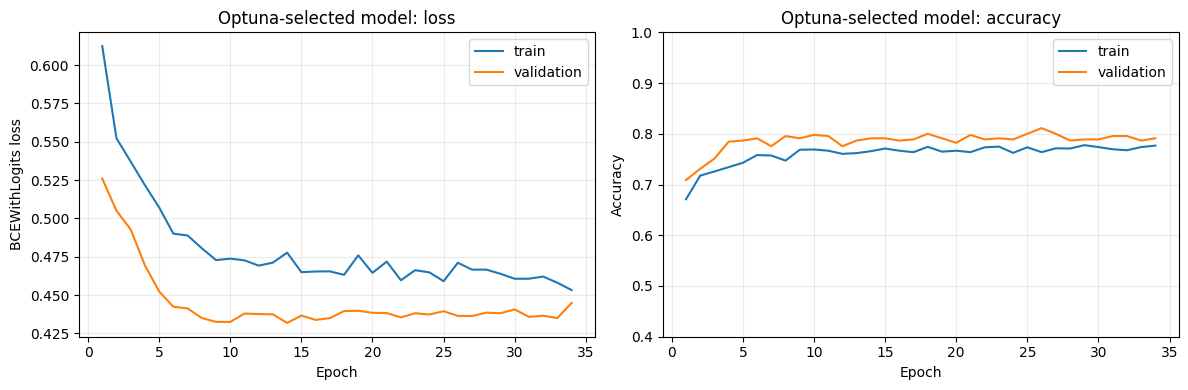

index | actual | probability
    0 |      1 |       0.374
    1 |      0 |       0.063
    2 |      1 |       0.864
    3 |      0 |       0.174
    4 |      0 |       0.069
    5 |      0 |       0.294
    6 |      1 |       0.463
    7 |      0 |       0.259
    8 |      0 |       0.057
    9 |      1 |       0.826


In [13]:
plot_learning_curves(selected_history, "Optuna-selected model")

test_probabilities = selected_trainer.predict_probabilities(x_test)
print("index | actual | probability")
for index in range(10):
    print(f"{index:>5} | {int(y_test[index].item()):>6} | {test_probabilities[index].item():>11.3f}")


### Save weights and preprocessing state

Save a `state_dict`, not the full Python model object. A real deployment also needs the feature order and standardisation statistics, so the checkpoint includes them. The save call is commented out to avoid creating files every time you run the tutorial.


In [14]:
checkpoint = {
    "model_state_dict": selected_trainer.model.state_dict(),
    "feature_names": feature_names,
    "standardizer_mean": normal_standardizer.mean,
    "standardizer_std": normal_standardizer.std,
    "model_parameters": {
        "hidden_sizes": architecture_options[best_parameters["architecture"]],
        "activation": best_parameters["activation"],
        "dropout": best_parameters["dropout"],
        "use_batch_norm": best_parameters["use_batch_norm"],
    },
}

# torch.save(checkpoint, "selected_customer_classifier.pt")
# loaded_checkpoint = torch.load("selected_customer_classifier.pt", map_location=DEVICE, weights_only=True)


## Step 8 - Walk-forward validation for time-ordered data

A random split is wrong when the row order represents time: it lets future patterns leak into the past. Walk-forward validation trains only on earlier observations and evaluates on the next block.

The windows below expand over time. Each fold fits a new standardiser on its own training window and a new model from scratch. The hyperparameters are fixed **before** the walk-forward run; in a production study, tune within each fold's training window if you need fold-specific selection.


In [15]:
@dataclass
class WalkForwardResult:
    fold: int
    train_rows: int
    validation_rows: int
    best_epoch: int
    validation_loss: float
    validation_accuracy: float


def expanding_window_splits(
    n_rows: int,
    initial_train_size: int,
    validation_size: int,
    step_size: int,
) -> list[tuple[slice, slice]]:
    splits: list[tuple[slice, slice]] = []
    train_end = initial_train_size

    while train_end + validation_size <= n_rows:
        train_slice = slice(0, train_end)
        validation_slice = slice(train_end, train_end + validation_size)
        splits.append((train_slice, validation_slice))
        train_end += step_size

    return splits


def run_walk_forward(
    features: torch.Tensor,
    targets: torch.Tensor,
    model_parameters: dict,
    config: TrainingConfig,
    initial_train_size: int = 1_200,
    validation_size: int = 300,
    step_size: int = 300,
) -> list[WalkForwardResult]:
    results: list[WalkForwardResult] = []
    splits = expanding_window_splits(
        n_rows=len(features),
        initial_train_size=initial_train_size,
        validation_size=validation_size,
        step_size=step_size,
    )

    for fold, (train_slice, validation_slice) in enumerate(splits, start=1):
        # Fit preprocessing only on information available at this point in time.
        fold_standardizer = TensorStandardizer().fit(features[train_slice])
        fold_x_train = fold_standardizer.transform(features[train_slice])
        fold_x_validation = fold_standardizer.transform(features[validation_slice])
        fold_y_train = targets[train_slice]
        fold_y_validation = targets[validation_slice]

        set_seed(SEED + fold)
        fold_model = MLPClassifier(input_size=features.shape[1], **model_parameters)
        fold_trainer = BinaryTrainer(fold_model, config, DEVICE)
        fold_train_loader = make_loader(fold_x_train, fold_y_train, config.batch_size, shuffle=True)
        fold_validation_loader = make_loader(
            fold_x_validation,
            fold_y_validation,
            config.batch_size,
            shuffle=False,
        )

        fold_trainer.fit(fold_train_loader, fold_validation_loader, verbose=False)
        validation_loss, validation_accuracy = fold_trainer.evaluate(fold_validation_loader)

        result = WalkForwardResult(
            fold=fold,
            train_rows=len(fold_x_train),
            validation_rows=len(fold_x_validation),
            best_epoch=fold_trainer.best_epoch,
            validation_loss=validation_loss,
            validation_accuracy=validation_accuracy,
        )
        results.append(result)
        print(
            f"Fold {fold}: train rows = {result.train_rows}, "
            f"validation rows = {result.validation_rows}, "
            f"best epoch = {result.best_epoch}, "
            f"validation accuracy = {result.validation_accuracy:.1%}"
        )

    return results


In [16]:
# Treat these as choices made before the time-based backtest starts.
# Do not use the random-split Optuna result here: that would mix future information into early folds.
walk_forward_model_parameters = {
    "hidden_sizes": (64, 32),
    "activation": "relu",
    "dropout": 0.10,
    "use_batch_norm": False,
}
walk_forward_config = TrainingConfig(
    epochs=80,
    batch_size=64,
    learning_rate=1e-3,
    weight_decay=1e-4,
    optimizer_name="adamw",
    early_stopping_patience=12,
)

walk_forward_results = run_walk_forward(
    features=raw_features,
    targets=labels,
    model_parameters=walk_forward_model_parameters,
    config=walk_forward_config,
)


Fold 1: train rows = 1200, validation rows = 300, best epoch = 19, validation accuracy = 73.0%
Fold 2: train rows = 1500, validation rows = 300, best epoch = 43, validation accuracy = 78.0%
Fold 3: train rows = 1800, validation rows = 300, best epoch = 13, validation accuracy = 75.0%
Fold 4: train rows = 2100, validation rows = 300, best epoch = 12, validation accuracy = 78.0%
Fold 5: train rows = 2400, validation rows = 300, best epoch = 25, validation accuracy = 77.3%
Fold 6: train rows = 2700, validation rows = 300, best epoch = 9, validation accuracy = 81.7%


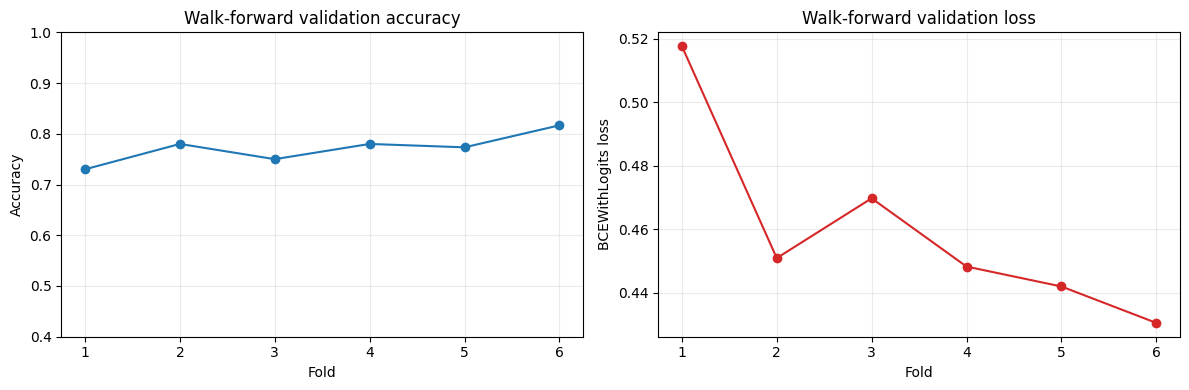

Mean walk-forward accuracy: 77.2%


In [17]:
fold_numbers = [result.fold for result in walk_forward_results]
fold_accuracy = [result.validation_accuracy for result in walk_forward_results]
fold_loss = [result.validation_loss for result in walk_forward_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fold_numbers, fold_accuracy, marker="o")
axes[0].set(title="Walk-forward validation accuracy", xlabel="Fold", ylabel="Accuracy", ylim=(0.4, 1.0))
axes[0].grid(alpha=0.25)

axes[1].plot(fold_numbers, fold_loss, marker="o", color="tab:red")
axes[1].set(title="Walk-forward validation loss", xlabel="Fold", ylabel="BCEWithLogits loss")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Mean walk-forward accuracy: {sum(fold_accuracy) / len(fold_accuracy):.1%}")


## Common mistakes to avoid

- **Using sigmoid before `BCEWithLogitsLoss`:** give the loss raw logits. Use sigmoid only when you need probabilities.
- **Leaving the model in training mode for validation:** dropout and batch normalisation behave differently; `BinaryTrainer` handles this through `model.train()` and `model.eval()`.
- **Not restoring the best epoch:** the final epoch is not automatically the best validation model. `EarlyStopping` stores and restores the best weights.
- **Scaling on all rows:** fitting a standardiser on validation or test rows is leakage.
- **Tuning on the test set:** Optuna should see training and validation data only.
- **Using a random split for time data:** use the walk-forward framework whenever future rows must remain unseen.
- **Changing many things at once:** record the seed, model parameters, split rule, and metric for every experiment.


## Final takeaway

A reliable DNN workflow has three layers of discipline:

1. **Data discipline:** split correctly for the problem and fit preprocessing only on training information.
2. **Training discipline:** use a clear `nn.Module`, a stable loss, mini-batches, early stopping, and proper train/eval modes.
3. **Selection discipline:** tune on validation data, then report test or walk-forward performance without leaking future information.

Replace the synthetic `raw_features` and `labels` with your own numeric dataset, preserve the surrounding workflow, and only then make task-specific changes such as class weighting, custom metrics, or a different output head.
